In [12]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [19]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

    def __init__(self, batch_size=32, learning_rate=0.0001, epochs=15):
      self.batch_size = batch_size
      self.learning_rate = learning_rate
      self.epochs = epochs

config = Config()

In [14]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        def double_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.down1 = double_conv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.down2 = double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.down3 = double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.down4 = double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.bottleneck = double_conv(512, 1024)

        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.up_conv1 = double_conv(1024, 512)
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv2 = double_conv(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv3 = double_conv(256, 128)
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv4 = double_conv(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        b = self.bottleneck(p4)

        u1 = self.up1(b)
        diffY = d4.size()[2] - u1.size()[2]
        diffX = d4.size()[3] - u1.size()[3]
        u1 = F.pad(u1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        u1 = self.up_conv1(torch.cat([d4, u1], dim=1))

        u2 = self.up2(u1)
        diffY = d3.size()[2] - u2.size()[2]
        diffX = d3.size()[3] - u2.size()[3]
        u2 = F.pad(u2, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        u2 = self.up_conv2(torch.cat([d3, u2], dim=1))

        u3 = self.up3(u2)
        diffY = d2.size()[2] - u3.size()[2]
        diffX = d2.size()[3] - u3.size()[3]
        u3 = F.pad(u3, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        u3 = self.up_conv3(torch.cat([d2, u3], dim=1))

        u4 = self.up4(u3)
        diffY = d1.size()[2] - u4.size()[2]
        diffX = d1.size()[3] - u4.size()[3]
        u4 = F.pad(u4, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        u4 = self.up_conv4(torch.cat([d1, u4], dim=1))

        return self.out_conv(u4)

In [15]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [16]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.train_losses = []
        self.val_losses = []
        self.val_ious = []
        self.val_f1_scores = []

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_ious.append(val_iou)
            self.val_f1_scores.append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img_original, mask_original = self.test_dataset[i]
                img_tensor = img_original.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                img_plot = img_original.permute(1, 2, 0).cpu().numpy()
                img_plot = (img_plot * 0.5) + 0.5
                img_plot = np.clip(img_plot, 0, 1)

                axes[i, 0].imshow(img_plot)
                axes[i, 0].set_title("Image")
                axes[i, 0].axis('off')

                axes[i, 1].imshow(mask_original.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 1].axis('off')

                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")
                axes[i, 2].axis('off')

            plt.tight_layout()
            plt.show()

    def plot_metrics(self):
        epochs_range = range(1, self.config.epochs + 1)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, self.train_losses, label='Train Loss')
        plt.plot(epochs_range, self.val_losses, label='Validation Loss')
        plt.title('Loss over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, self.val_ious, label='Validation IoU')
        plt.plot(epochs_range, self.val_f1_scores, label='Validation F1-score')
        plt.title('Metrics over Epochs (U-Net)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

In [20]:
learning_rates = [0.001, 0.0005, 0.0001]
batch_sizes = [16, 32, 64]

results = []
best_config_unet = config
max_val_f1 = 0

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"--- Starting training for LR: {lr}, Batch Size: {bs} ---")
        current_config = Config(
            batch_size=bs,
            learning_rate=lr,
            epochs=3
        )
        current_trainer = Trainer(current_config)
        current_trainer.run()

        if max_val_f1 < max(current_trainer.val_f1_scores):
          best_config_unet = current_config
          max_val_f1 = max(current_trainer.val_f1_scores)

        results.append({
            'learning_rate': lr,
            'batch_size': bs,
            'max_val_f1': max_val_f1
        })
        print(f"Finished training for LR: {lr}, Batch Size: {bs}. Val F1: {max(current_trainer.val_f1_scores):.4f}")

print("--- Hyperparameter Search Complete ---")
for res in results:
    print(f"LR: {res['learning_rate']}, BS: {res['batch_size']}, Max Val F1: {res['max_val_f1']:.4f}")

best_result = max(results, key=lambda x: x['max_val_f1'])
print(f"Best configuration: LR: {best_result['learning_rate']}, BS: {best_result['batch_size']}, Max Val F1: {best_result['max_val_f1']:.4f}")
best_config_unet.epochs = 15

--- Starting training for LR: 0.001, Batch Size: 16 ---


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:12<00:00,  3.56it/s]


Epoch 1 / 3, Train Loss: 0.5833, Val Loss: 0.4917, Val IoU: 0.7285, Val F1-score: 0.8330


100%|██████████| 46/46 [00:13<00:00,  3.35it/s]


Epoch 2 / 3, Train Loss: 0.4420, Val Loss: 0.4326, Val IoU: 0.7472, Val F1-score: 0.8498


...

Epoch 2 / 3, Train Loss: 0.5429, Val Loss: 0.5004, Val IoU: 0.7315, Val F1-score: 0.8347


100%|██████████| 12/12 [00:14<00:00,  1.24s/it]


Epoch 3 / 3, Train Loss: 0.4721, Val Loss: 0.4534, Val IoU: 0.7552, Val F1-score: 0.8533
Testing...


100%|██████████| 58/58 [01:13<00:00,  1.27s/it]

Test Loss: 0.4508, Test IoU: 0.7515, Test F1-score: 0.8497
Finished training for LR: 0.0001, Batch Size: 64. Val F1: 0.8533
--- Hyperparameter Search Complete ---
LR: 0.001, BS: 16, Max Val F1: 0.8586
LR: 0.001, BS: 32, Max Val F1: 0.8601
LR: 0.001, BS: 64, Max Val F1: 0.8650
LR: 0.0005, BS: 16, Max Val F1: 0.8650
LR: 0.0005, BS: 32, Max Val F1: 0.8650
LR: 0.0005, BS: 64, Max Val F1: 0.8650
LR: 0.0001, BS: 16, Max Val F1: 0.8650
LR: 0.0001, BS: 32, Max Val F1: 0.8650
LR: 0.0001, BS: 64, Max Val F1: 0.8650
Best configuration: LR: 0.001, BS: 64, Max Val F1: 0.8650


In [21]:
trainer_unet = Trainer(best_config_unet)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [22]:
trainer_unet.run()

100%|██████████| 12/12 [00:14<00:00,  1.25s/it]


Epoch 1 / 15, Train Loss: 0.7350, Val Loss: 0.6594, Val IoU: 0.6947, Val F1-score: 0.8077


100%|██████████| 12/12 [00:14<00:00,  1.20s/it]


Epoch 2 / 15, Train Loss: 0.5623, Val Loss: 0.5138, Val IoU: 0.6947, Val F1-score: 0.8077


100%|██████████| 12/12 [00:11<00:00,  1.02it/s]


...

Epoch 14 / 15, Train Loss: 0.3052, Val Loss: 0.3153, Val IoU: 0.8068, Val F1-score: 0.8871


100%|██████████| 12/12 [00:14<00:00,  1.22s/it]


Epoch 15 / 15, Train Loss: 0.2902, Val Loss: 0.3001, Val IoU: 0.8203, Val F1-score: 0.8957
Testing...


100%|██████████| 58/58 [01:08<00:00,  1.17s/it]

Test Loss: 0.2955, Test IoU: 0.8220, Test F1-score: 0.8962


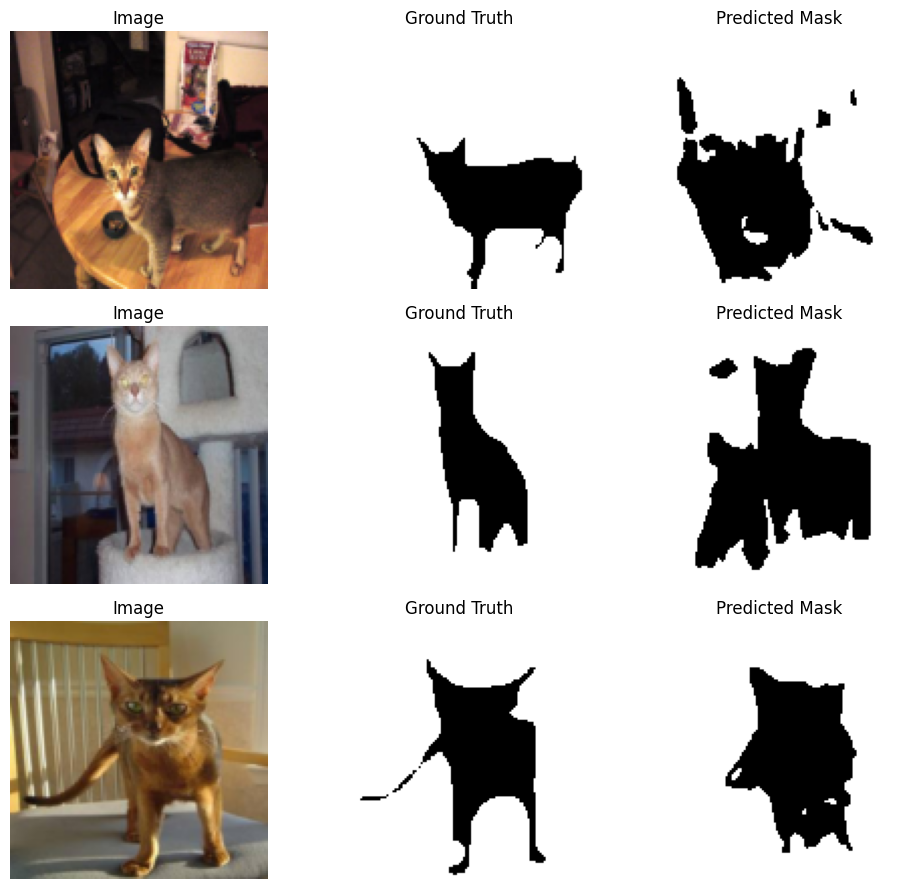

In [23]:
trainer_unet.inference_and_plot_samples(n_samples=3)

In [24]:
class NestedUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(NestedUNet, self).__init__()

        def double_conv(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        nb_filter = [64, 128, 256, 512, 1024]

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.conv0_0 = double_conv(in_channels, nb_filter[0])
        self.conv1_0 = double_conv(nb_filter[0], nb_filter[1])
        self.conv2_0 = double_conv(nb_filter[1], nb_filter[2])
        self.conv3_0 = double_conv(nb_filter[2], nb_filter[3])
        self.conv4_0 = double_conv(nb_filter[3], nb_filter[4])

        self.conv0_1 = double_conv(nb_filter[0] + nb_filter[1], nb_filter[0])
        self.conv1_1 = double_conv(nb_filter[1] + nb_filter[2], nb_filter[1])
        self.conv2_1 = double_conv(nb_filter[2] + nb_filter[3], nb_filter[2])
        self.conv3_1 = double_conv(nb_filter[3] + nb_filter[4], nb_filter[3])

        self.conv0_2 = double_conv(nb_filter[0]*2 + nb_filter[1], nb_filter[0])
        self.conv1_2 = double_conv(nb_filter[1]*2 + nb_filter[2], nb_filter[1])
        self.conv2_2 = double_conv(nb_filter[2]*2 + nb_filter[3], nb_filter[2])

        self.conv0_3 = double_conv(nb_filter[0]*3 + nb_filter[1], nb_filter[0])
        self.conv1_3 = double_conv(nb_filter[1]*3 + nb_filter[2], nb_filter[1])

        self.conv0_4 = double_conv(nb_filter[0]*4 + nb_filter[1], nb_filter[0])

        self.final = nn.Conv2d(nb_filter[0], out_channels, kernel_size=1)

    def forward(self, x):
        x0_0 = self.conv0_0(x)
        x1_0 = self.conv1_0(self.pool(x0_0))
        x0_1 = self.conv0_1(torch.cat([x0_0, self._upsample_pad(x1_0, x0_0)], 1))

        x2_0 = self.conv2_0(self.pool(x1_0))
        x1_1 = self.conv1_1(torch.cat([x1_0, self._upsample_pad(x2_0, x1_0)], 1))
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, self._upsample_pad(x1_1, x0_0)], 1))

        x3_0 = self.conv3_0(self.pool(x2_0))
        x2_1 = self.conv2_1(torch.cat([x2_0, self._upsample_pad(x3_0, x2_0)], 1))
        x1_2 = self.conv1_2(torch.cat([x1_0, x1_1, self._upsample_pad(x2_1, x1_0)], 1))
        x0_3 = self.conv0_3(torch.cat([x0_0, x0_1, x0_2, self._upsample_pad(x1_2, x0_0)], 1))

        x4_0 = self.conv4_0(self.pool(x3_0))
        x3_1 = self.conv3_1(torch.cat([x3_0, self._upsample_pad(x4_0, x3_0)], 1))
        x2_2 = self.conv2_2(torch.cat([x2_0, x2_1, self._upsample_pad(x3_1, x2_0)], 1))
        x1_3 = self.conv1_3(torch.cat([x1_0, x1_1, x1_2, self._upsample_pad(x2_2, x1_0)], 1))
        x0_4 = self.conv0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self._upsample_pad(x1_3, x0_0)], 1))

        output = self.final(x0_4)
        return output

    def _upsample_pad(self, x, target):
        x = self.up(x)
        diffY = target.size()[2] - x.size()[2]
        diffX = target.size()[3] - x.size()[3]
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        return x

In [25]:
class NestedTrainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = NestedUNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.train_losses = []
        self.val_losses = []
        self.val_ious = []
        self.val_f1_scores = []

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_ious.append(val_iou)
            self.val_f1_scores.append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img_original, mask_original = self.test_dataset[i]
                img_tensor = img_original.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                img_plot = img_original.permute(1, 2, 0).cpu().numpy()
                img_plot = (img_plot * 0.5) + 0.5
                img_plot = np.clip(img_plot, 0, 1)

                axes[i, 0].imshow(img_plot)
                axes[i, 0].set_title("Image")
                axes[i, 0].axis('off')

                axes[i, 1].imshow(mask_original.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 1].axis('off')

                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")
                axes[i, 2].axis('off')

            plt.tight_layout()
            plt.show()

    def plot_metrics(self):
        epochs_range = range(1, self.config.epochs + 1)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, self.train_losses, label='Train Loss')
        plt.plot(epochs_range, self.val_losses, label='Validation Loss')
        plt.title('Loss over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, self.val_ious, label='Validation IoU')
        plt.plot(epochs_range, self.val_f1_scores, label='Validation F1-score')
        plt.title('Metrics over Epochs (Nested U-Net)')
        plt.xlabel('Epoch')
        plt.ylabel('Score')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()

In [28]:
learning_rates = [0.001, 0.0005, 0.0001]
batch_sizes = [16] # Батч сайз больше тупа не лезет в память

results = []
best_config_nested_unet = config
max_val_f1 = 0

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"--- Starting training for LR: {lr}, Batch Size: {bs} ---")
        current_config = Config(
            batch_size=bs,
            learning_rate=lr,
            epochs=3
        )
        current_trainer = NestedTrainer(current_config)
        current_trainer.run()

        if max_val_f1 < max(current_trainer.val_f1_scores):
          best_config_nested_unet = current_config
          max_val_f1 = max(current_trainer.val_f1_scores)

        results.append({
            'learning_rate': lr,
            'batch_size': bs,
            'max_val_f1': max_val_f1
        })
        print(f"Finished training for LR: {lr}, Batch Size: {bs}. Val F1: {max(current_trainer.val_f1_scores):.4f}")

print("--- Hyperparameter Search Complete ---")
for res in results:
    print(f"LR: {res['learning_rate']}, BS: {res['batch_size']}, Max Val F1: {res['max_val_f1']:.4f}")

best_result = max(results, key=lambda x: x['max_val_f1'])
print(f"Best configuration: LR: {best_result['learning_rate']}, BS: {best_result['batch_size']}, Max Val F1: {best_result['max_val_f1']:.4f}")
best_config_nested_unet.epochs = 15

--- Starting training for LR: 0.001, Batch Size: 16 ---


100%|██████████| 46/46 [00:19<00:00,  2.36it/s]


Epoch 1 / 3, Train Loss: 0.5787, Val Loss: 0.4384, Val IoU: 0.7538, Val F1-score: 0.8540


100%|██████████| 46/46 [00:19<00:00,  2.35it/s]


Epoch 2 / 3, Train Loss: 0.4410, Val Loss: 0.4097, Val IoU: 0.7588, Val F1-score: 0.8579


...

Epoch 2 / 3, Train Loss: 0.4237, Val Loss: 0.4028, Val IoU: 0.7757, Val F1-score: 0.8663


100%|██████████| 46/46 [00:19<00:00,  2.41it/s]


Epoch 3 / 3, Train Loss: 0.3956, Val Loss: 0.3977, Val IoU: 0.7832, Val F1-score: 0.8707
Testing...


100%|██████████| 230/230 [01:36<00:00,  2.37it/s]

Test Loss: 0.3974, Test IoU: 0.7783, Test F1-score: 0.8667
Finished training for LR: 0.0001, Batch Size: 16. Val F1: 0.8707
--- Hyperparameter Search Complete ---
LR: 0.001, BS: 16, Max Val F1: 0.8579
LR: 0.0005, BS: 16, Max Val F1: 0.8579
LR: 0.0001, BS: 16, Max Val F1: 0.8707
Best configuration: LR: 0.0001, BS: 16, Max Val F1: 0.8707


In [29]:
trainer_nested_unet = Trainer(best_config_unet)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [30]:
trainer_nested_unet.run()

100%|██████████| 12/12 [00:12<00:00,  1.04s/it]


Epoch 1 / 15, Train Loss: 0.6349, Val Loss: 0.6155, Val IoU: 0.7001, Val F1-score: 0.8118


100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


Epoch 2 / 15, Train Loss: 0.5429, Val Loss: 0.4714, Val IoU: 0.6769, Val F1-score: 0.8010


100%|██████████| 12/12 [00:12<00:00,  1.03s/it]


...

Epoch 14 / 15, Train Loss: 0.2875, Val Loss: 0.2991, Val IoU: 0.8255, Val F1-score: 0.8993


100%|██████████| 12/12 [00:14<00:00,  1.18s/it]


Epoch 15 / 15, Train Loss: 0.2694, Val Loss: 0.2750, Val IoU: 0.8369, Val F1-score: 0.9061
Testing...


100%|██████████| 58/58 [01:10<00:00,  1.22s/it]

Test Loss: 0.2648, Test IoU: 0.8432, Test F1-score: 0.9095


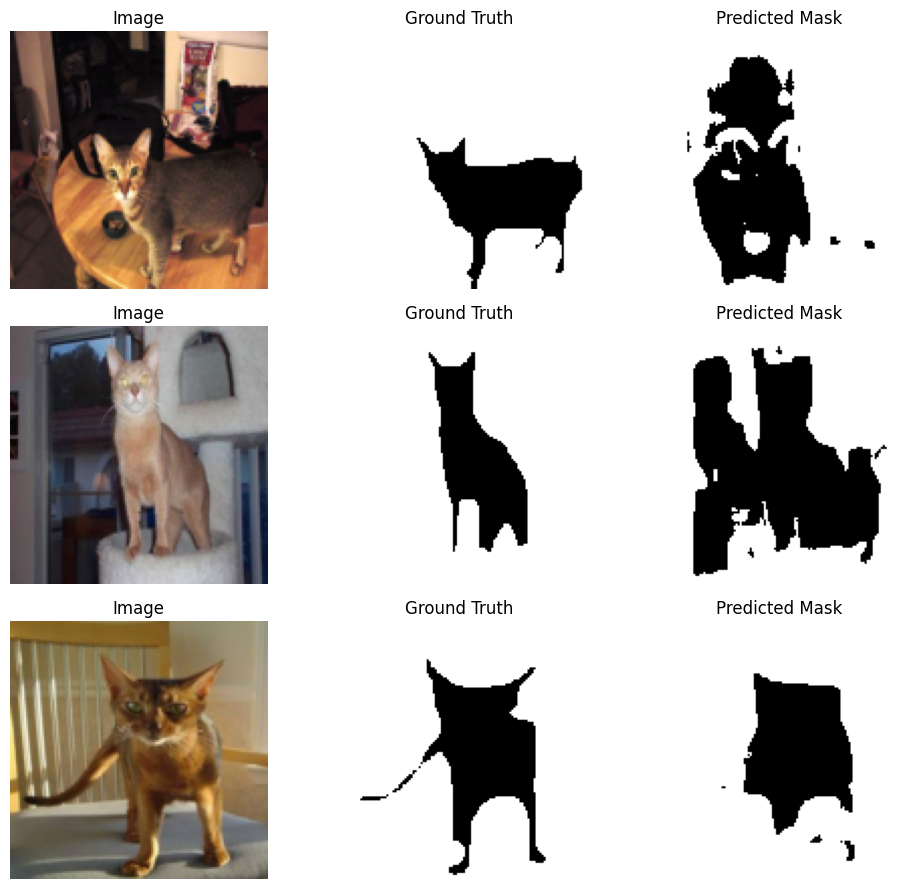

In [31]:
trainer_nested_unet.inference_and_plot_samples(n_samples=3)

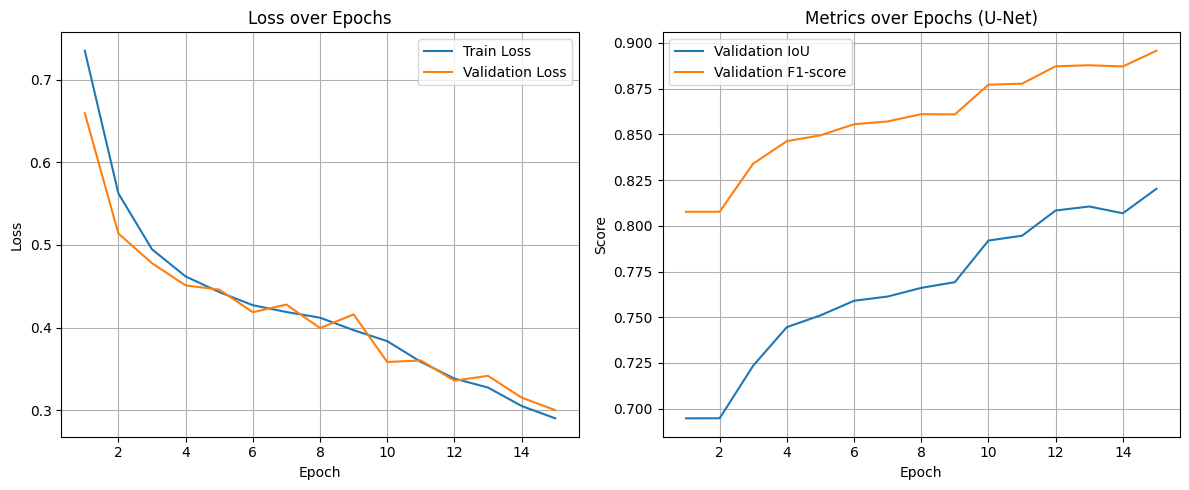

In [32]:
trainer_unet.plot_metrics()

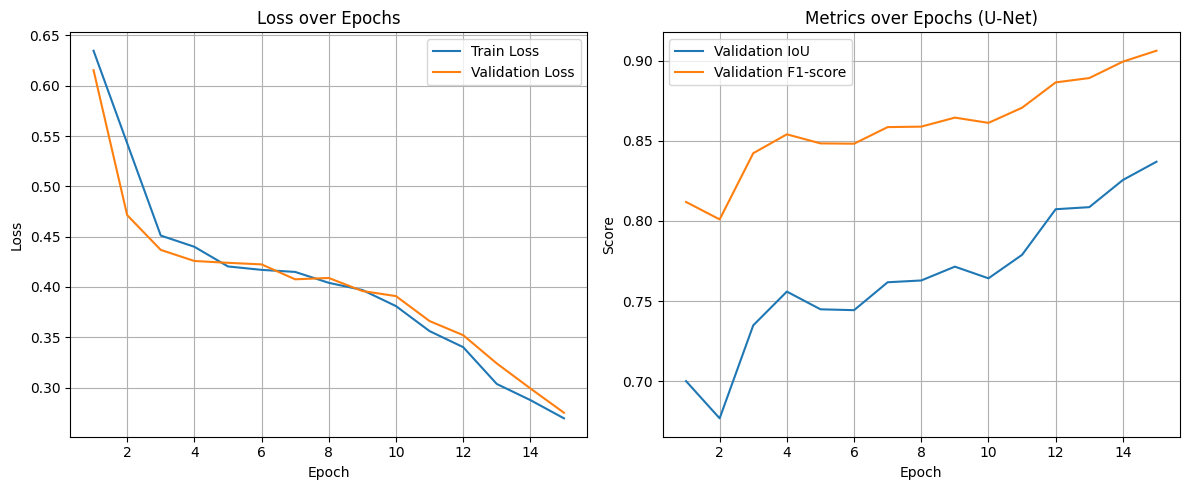

In [33]:
trainer_nested_unet.plot_metrics()

### Выводы

*   **Learning Rate (0.0005):** Этот learning rate оказался оптимальным в ходе короткого поиска, обеспечив лучший баланс между скоростью сходимости и стабильностью обучения. Более высокий LR (0.001) мог вызывать перескакивание через оптимум, а более низкий (0.0001) — замедленную сходимость, что не позволило бы достичь высоких метрик за 3 эпохи.
*   **Batch Size (16):** Меньший размер батча (16) в данном случае оказался эффективнее, чем 32 или 64. Меньшие батчи могут способствовать лучшей генерализации, добавляя немного шума в оценку градиента, что помогает избежать попадания в мелкие локальные минимумы. Это также может быть связано с более сложной функцией потерь для сегментации.
*   **Метрики моделей:** Улучшение Nested U-Net действительно позволил повысить f1. Но на самом деле качество при таком коротком обучении всё равно чрезвычайно плохое, маски слишком шумные